# Лабораторная работа 1. Уменьшение объема данных
## Статистические методы отбора признаков
### Потоцкий Д.А., гр. 221702

## 1. Задание 1: Отбор признаков с использованием корреляционных матриц.

Корреляционная матрица, визуализированная с помощью seaborn, датасета о винах из sklearn.datasets:

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

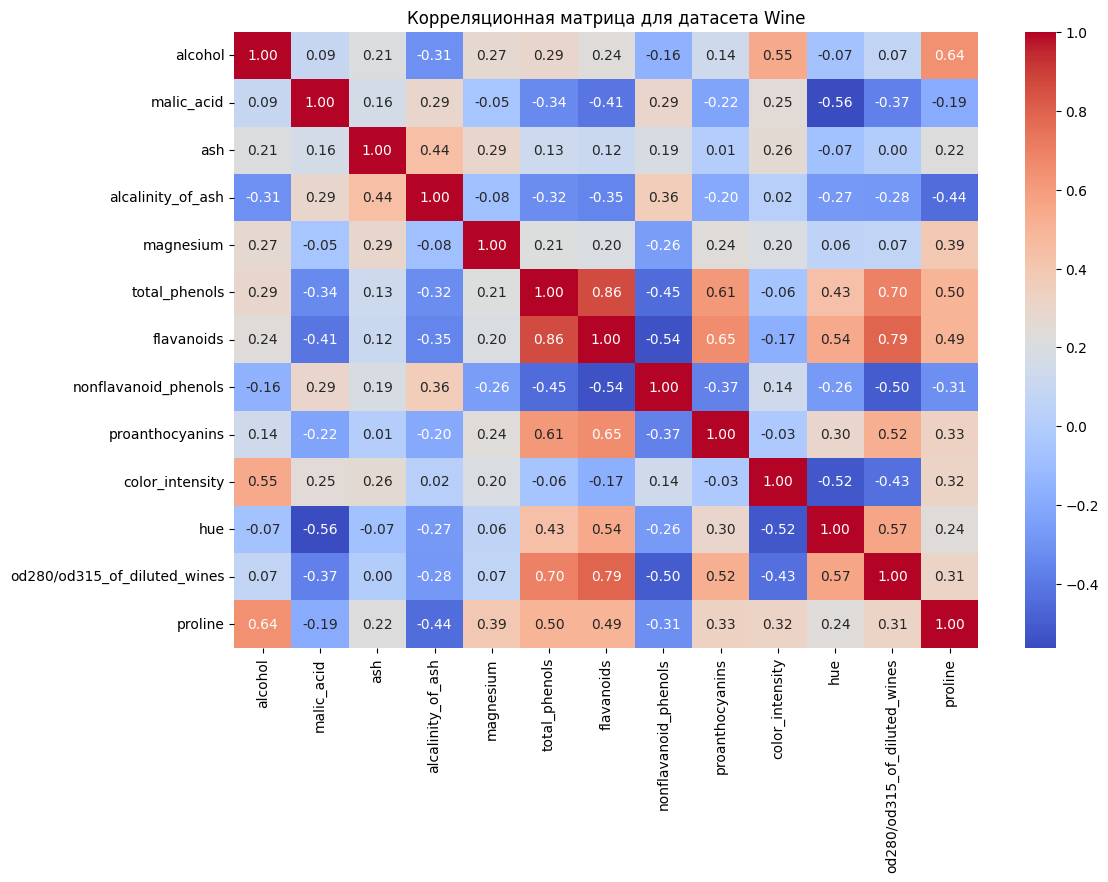

In [ ]:
# Загрузка данных
data = load_wine()
df = pd.DataFrame(data.data, columns=data.feature_names)

# Корреляционная матрица
corr_matrix = df.corr()

# Визуализация корреляционной матрицы
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Корреляционная матрица для датасета Wine")
plt.show()

Загрузка другой модели и оценка корреляционной матрицы:

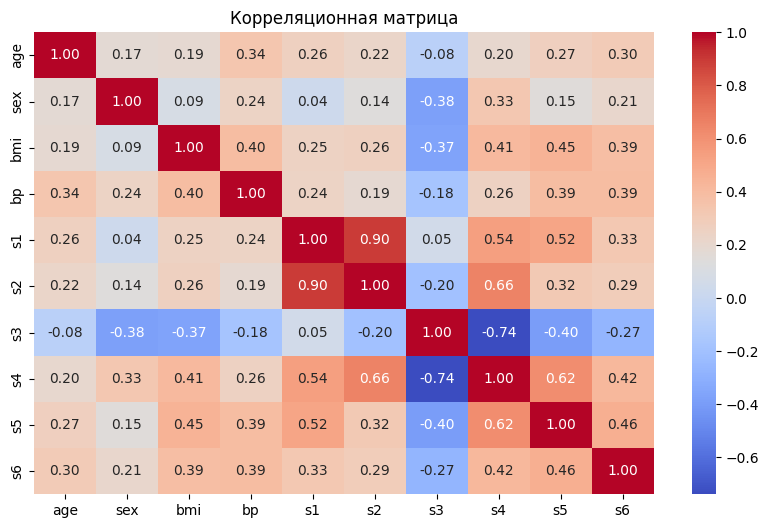

In [ ]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Загрузка данных
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
X = df
y = data.target

# Корреляционная матрица
corr_matrix = X.corr()

# Визуализация корреляционной матрицы
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Корреляционная матрица")
plt.show()

**Признаки:**

age: Возраст пациента (в годах).

sex: Пол пациента (0 — женский, 1 — мужской).

bmi: Индекс массы тела (Body Mass Index), рассчитывается как вес (кг) / (рост (м))².

bp: Среднее артериальное давление (Average Blood Pressure).

s1: Уровень общего холестерина (Total Serum Cholesterol).

s2: Уровень липопротеинов низкой плотности (LDL, Low-Density Lipoproteins).

s3: Уровень липопротеинов высокой плотности (HDL, High-Density Lipoproteins).

s4: Уровень общего холестерина / HDL (Total Cholesterol / HDL Ratio).

s5: Уровень логарифма триглицеридов (Log of Serum Triglycerides Level).

s6: Уровень глюкозы в крови (Blood Sugar Level).

**Целевая переменная:**

target: Количественная мера прогрессирования заболевания через один год. Это непрерывная переменная, которая используется для задачи регрессии.

Удаление признаков с корреляцией > 0.8

In [ ]:
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
to_drop = [column for column in upper.columns if any(abs(upper[column]) > 0.8)]
X = X.drop(columns=to_drop)

print("Удалённые признаки:", to_drop)

Удалённые признаки: ['s2']


Обучение модели и оценка производительности:

In [ ]:
# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Обучение модели линейной регрессии
model = LinearRegression()
model.fit(X_train, y_train)

# Оценка
y_pred = model.predict(X_test)
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))

Mean Squared Error (MSE): 2900.2541204090467
R^2 Score: 0.4525913454213403


## 2. Задание 2: Отбор признаков на основе важности признаков в случайном лесе.

Подогнать модель **RandomForestRegressor** к данным и используя атрибут feature_importances_ определить наиболее важные признаки:

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [ ]:
# Разделение данных
X = df
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Обучение Random Forest для определения важных признаков
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

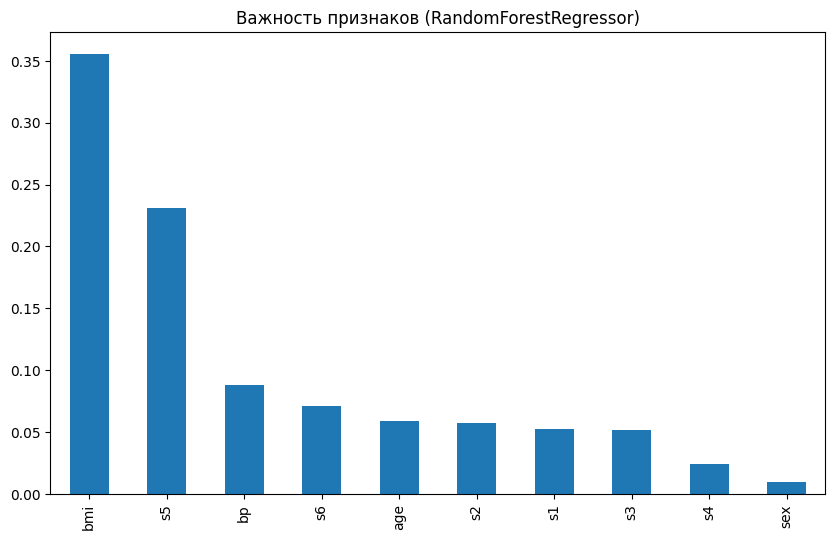

In [ ]:
# Важность признаков
feature_importances = pd.Series(rf_model.feature_importances_, index=data.feature_names)
feature_importances.sort_values(ascending=False).plot(kind='bar', figsize=(10, 6))
plt.title("Важность признаков (RandomForestRegressor)")
plt.show()

Оставляем признаки, у которых важность более 0,1:

In [ ]:
# Определение важных признаков
feature_importances = pd.Series(rf_model.feature_importances_, index=data.feature_names)
important_features = feature_importances[feature_importances > 0.1].index
X_train_imp = X_train[important_features]
X_test_imp = X_test[important_features]
print("Важные признаки:", important_features)

Важные признаки: Index(['bmi', 's5'], dtype='object')


Обучение модели и оценка производительности:

In [ ]:
# Использование линейной регрессии на важных признаках
lr_model = LinearRegression()
lr_model.fit(X_train_imp, y_train)

# Прогнозирование
y_pred = lr_model.predict(X_test_imp)

# Оценка модели
print("MSE:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))

MSE: 2901.8369415567036
R^2 Score: 0.4522925957397932


## 3. Задание 3: Использование выбора признаков на основе p-value.

In [ ]:
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.feature_selection import f_regression

Boston Housing отказался работать, поэтому используется **fetch_california_housing**

In [ ]:
# Загрузка данных
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
X = df
y = data.target

# Расчет p-value
f_values, p_values = f_regression(X, y)

# Вывод признаков с их p-value
feature_p_values = pd.Series(p_values, index=data.feature_names)
print("P-values:\n", feature_p_values.sort_values())

P-values:
 bmi    3.466006e-42
s5     8.826459e-39
bp     1.649372e-22
s4     2.304253e-21
s3     6.162865e-18
s6     7.580083e-17
s1     6.920712e-06
age    7.055686e-05
s2     2.359848e-04
sex    3.664293e-01
dtype: float64


Выбор признаков по p-value

In [ ]:
f_values, p_values = f_regression(X, y)
selected_features = X.columns[p_values < 1e-12]
X = X[selected_features]
print("Выбранные признаки", selected_features)

Выбранные признаки Index(['bmi', 'bp', 's3', 's4', 's5', 's6'], dtype='object')


Обучение модели и оценка производительности:

In [ ]:
# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Обучение модели
model = LinearRegression()
model.fit(X_train, y_train)

# Оценка
y_pred = model.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))

MSE: 2931.0406900974717
R^2 Score: 0.44678053230202086


## 4. Задание 4: Отбор признаков с помощь метода взаимной информации.

In [ ]:
from sklearn.feature_selection import mutual_info_regression

In [ ]:
data = load_diabetes()

In [ ]:
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
X = df
y = data.target

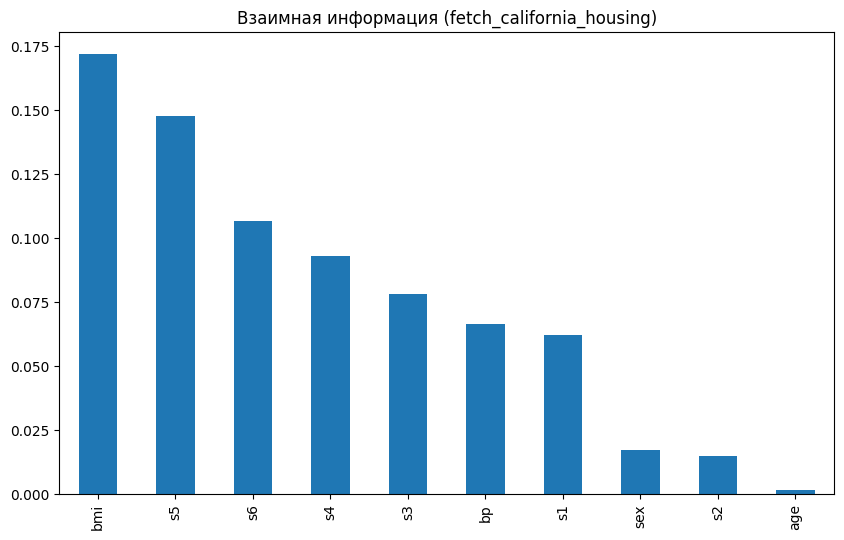

In [ ]:
# Расчет взаимной информации
mutual_info = mutual_info_regression(X, y)
mutual_info_series = pd.Series(mutual_info, index=data.feature_names)

# Визуализация
mutual_info_series.sort_values(ascending=False).plot(kind='bar', figsize=(10, 6))
plt.title("Взаимная информация (fetch_california_housing)")
plt.show()

In [ ]:
# Топ-5 признаков
top_features = mutual_info_series.sort_values(ascending=False).head(5).index
X = df[top_features]

In [ ]:
print("Топ 5 признаков", top_features)

Топ 5 признаков Index(['bmi', 's5', 's6', 's4', 's3'], dtype='object')


Обучение модели и оценка производительности:

In [ ]:
# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Обучение модели
model = LinearRegression()
model.fit(X_train, y_train)

# Оценка
y_pred = model.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))

MSE: 2889.0537056531925
R^2 Score: 0.4547053684405922


## 5. Задание 5: Используйте метод Recursive Feature Elimination на том же датасете.

Построить модель используя линейную регрессию, используется RFE для выбора лучшего подмножества признаков.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE

In [ ]:
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
X = df
y = data.target

In [ ]:
model = LinearRegression()

In [ ]:
# RFE
rfe = RFE(estimator=model, n_features_to_select=2)
rfe.fit(X, y)

# Вывод выбранных признаков
selected_features = pd.Series(rfe.support_, index=data.feature_names)
print("Выбранные признаки (RFE):\n", selected_features[selected_features == True].index)

Выбранные признаки (RFE):
 Index(['bmi', 's5'], dtype='object')


Обучение модели и оценка производительности:

In [ ]:
model.fit(X_train, y_train)

# Оценка
y_pred = model.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))

MSE: 2889.0537056531925
R^2 Score: 0.4547053684405922
